In [1]:
import importlib
from ultralytics import YOLO
import supervision as sv
import numpy as np
import cv2
import sys
sys.path.append("..")

from media_tools import video_tools as vt
from media_tools import image_tools as it
importlib.reload(vt)
importlib.reload(it)

<module 'media_tools.image_tools' from '/home/adrian/IA-Futbol/field_localization/../media_tools/image_tools.py'>

In [2]:
dataset = "dataset/field_localization"

In [4]:
import json
import cv2
import matplotlib.pyplot as plt

def draw_soccer_field(file_number, folder_path="", draw_curves=False, field_name=None, save_path=None):
    """
    Dibuja los puntos o curvas del JSON de SoccerNet sobre la imagen.

    Args:
        file_number (str): Número del archivo, por ejemplo "00001".
        folder_path (str): Carpeta donde están los archivos.
        draw_curves (bool): Si True dibuja líneas entre los puntos; si False, solo puntos.
        field_name (str or None): Nombre del campo a dibujar. Si None, dibuja todos.
        save_path (str): Ruta para guardar la imagen (opcional).
    """
    image_path = f'/home/adrian/IA-Futbol/dataset/field_localization/train/00016.jpg'
    json_path = f'/home/adrian/IA-Futbol/dataset/field_localization/train/00016.json'

    # Cargamos la imagen
    image = cv2.imread(image_path)
    if image is None:
        print(f"No se pudo cargar la imagen {image_path}")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Cargamos el JSON
    with open(json_path, 'r') as f:
        data = json.load(f)

    height, width, _ = image.shape

    # Seleccionamos los campos a dibujar
    if field_name:
        fields_to_draw = {field_name: data.get(field_name, [])}
    else:
        fields_to_draw = data

    # Dibujamos cada campo
    for key, points in fields_to_draw.items():
        if draw_curves and len(points) > 1:
            # Dibujar líneas entre puntos
            pts = [(int(p['x']*width), int(p['y']*height)) for p in points]
            for i in range(len(pts)-1):
                cv2.line(image, pts[i], pts[i+1], (0, 255, 0), 2)
        else:
            # Dibujar solo puntos
            for p in points:
                x = int(p['x'] * width)
                y = int(p['y'] * height)
                cv2.circle(image, (x, y), 5, (255, 0, 0), -1)

    # Mostramos la imagen
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Soccer Field Visualization - {file_number}")
    plt.show()

    # Guardamos la imagen si se indica
    if save_path:
        cv2.imwrite(save_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
        print(f"Imagen guardada en {save_path}")


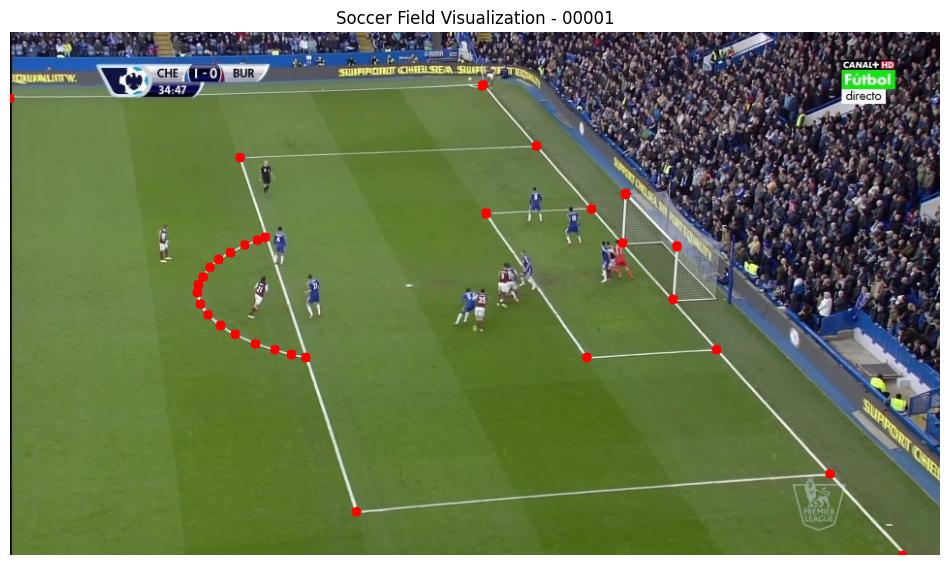

In [6]:
draw_soccer_field("00001", draw_curves=False)


In [58]:
from transformers import AutoImageProcessor, SuperPointForKeypointDetection
import torch
from PIL import Image
import requests

url = "00001.jpg"
image = Image.open(url)


processor = AutoImageProcessor.from_pretrained("magic-leap-community/superpoint")
model = SuperPointForKeypointDetection.from_pretrained("magic-leap-community/superpoint")

inputs = processor(image, return_tensors="pt")
outputs = model(**inputs)

In [59]:
outputs.keypoints

tensor([[[0.1547, 0.0167],
         [0.3547, 0.0167],
         [0.0312, 0.0188],
         ...,
         [0.8687, 0.9521],
         [0.3547, 0.9625],
         [0.7391, 0.9646]]])

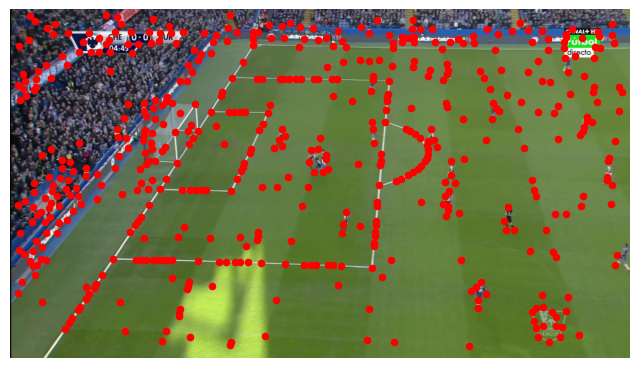

In [57]:
keypoints = outputs.keypoints[0]  # Forma: (N, 2) en coordenadas normalizadas [0, 1]

# Extraer scores si quieres usarlo para tamaño/color
scores = outputs.scores[0]  # Forma: (N,)

# Convertir a numpy
keypoints = keypoints.detach().cpu().numpy()
scores = scores.detach().cpu().numpy()

# Obtener tamaño de la imagen
w, h = image.size

# Escalar keypoints a coordenadas de píxeles
keypoints[:, 0] *= w  # x
keypoints[:, 1] *= h  # y

# Dibujar imagen y keypoints
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.scatter(keypoints[:, 0], keypoints[:, 1], c='r', s=20)
plt.axis('off')
plt.show()

In [ ]:
if 'torch' in str(type(keypoints)):
    keypoints = keypoints.cpu().numpy()

h, w = image.shape[:2]
# Escalar si los keypoints están normalizados
if keypoints.max() <= 1.0:
    keypoints[:, 0] *= w  # x
    keypoints[:, 1] *= h  # y

plt.figure(figsize=(8, 6))
plt.imshow(image, cmap='gray')
# Scatter requiere coordenadas x e y
plt.scatter(keypoints[:, 0], keypoints[:, 1], c=color, s=size)
plt.axis('off')
plt.show()

In [56]:
outputs



SuperPointKeypointDescriptionOutput(loss=None, keypoints=tensor([[[0.1547, 0.0167],
         [0.3547, 0.0167],
         [0.0312, 0.0188],
         ...,
         [0.8687, 0.9521],
         [0.3547, 0.9625],
         [0.7391, 0.9646]]]), scores=tensor([[0.0088, 0.0434, 0.0114, 0.3021, 0.0062, 0.0062, 0.3009, 0.0548, 0.0301, 0.0516, 0.1054, 0.1947, 0.1458, 0.0161, 0.0055, 0.0073, 0.4214, 0.0769, 0.0956, 0.0589, 0.0190, 0.1832, 0.0071, 0.0974, 0.0060, 0.0081, 0.0093, 0.2404, 0.0612, 0.0321, 0.3634, 0.2972, 0.3964, 0.3195, 0.3564, 0.1403, 0.0055, 0.0993, 0.5619,
         0.4257, 0.3549, 0.2762, 0.0181, 0.0505, 0.1324, 0.0129, 0.1961, 0.0836, 0.0371, 0.3293, 0.0093, 0.1076, 0.1236, 0.1936, 0.0067, 0.1007, 0.1461, 0.3446, 0.3100, 0.0052, 0.1177, 0.0188, 0.1231, 0.0782, 0.1653, 0.0163, 0.0109, 0.0091, 0.2179, 0.4825, 0.2124, 0.3640, 0.0933, 0.0187, 0.0280, 0.0190, 0.4003, 0.2667,
         0.2013, 0.0354, 0.3152, 0.0846, 0.0220, 0.3571, 0.2823, 0.1152, 0.4572, 0.1943, 0.3746, 0.0342, 0.0250, 0.

ValueError: s must be a scalar, or float array-like with the same size as x and y

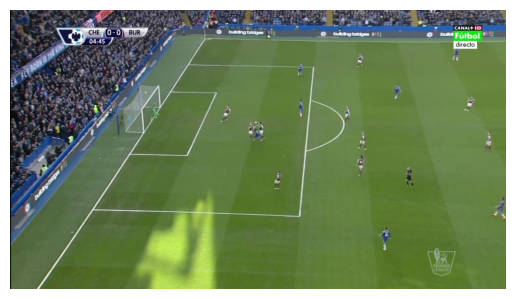

In [54]:
import matplotlib.pyplot as plt

plt.axis("off")
plt.imshow(image)
plt.scatter(
    outputs[1][:, 0].detach().cpu().numpy(),
    outputs[1][:, 1].detach().cpu().numpy(),
    c=(outputs[2] * 100).detach().cpu().numpy(),
    s=(outputs[2] * 50).detach().cpu().numpy(),
    alpha=0.8
)
plt.savefig(f"output_image.png")

In [29]:
outputs

SuperPointKeypointDescriptionOutput(loss=None, keypoints=tensor([[[0.1547, 0.0167],
         [0.3547, 0.0167],
         [0.0312, 0.0188],
         ...,
         [0.8687, 0.9521],
         [0.3547, 0.9625],
         [0.7391, 0.9646]]]), scores=tensor([[0.0088, 0.0434, 0.0114, 0.3021, 0.0062, 0.0062, 0.3009, 0.0548, 0.0301, 0.0516, 0.1054, 0.1947, 0.1458, 0.0161, 0.0055, 0.0073, 0.4214, 0.0769, 0.0956, 0.0589, 0.0190, 0.1832, 0.0071, 0.0974, 0.0060, 0.0081, 0.0093, 0.2404, 0.0612, 0.0321, 0.3634, 0.2972, 0.3964, 0.3195, 0.3564, 0.1403, 0.0055, 0.0993, 0.5619,
         0.4257, 0.3549, 0.2762, 0.0181, 0.0505, 0.1324, 0.0129, 0.1961, 0.0836, 0.0371, 0.3293, 0.0093, 0.1076, 0.1236, 0.1936, 0.0067, 0.1007, 0.1461, 0.3446, 0.3100, 0.0052, 0.1177, 0.0188, 0.1231, 0.0782, 0.1653, 0.0163, 0.0109, 0.0091, 0.2179, 0.4825, 0.2124, 0.3640, 0.0933, 0.0187, 0.0280, 0.0190, 0.4003, 0.2667,
         0.2013, 0.0354, 0.3152, 0.0846, 0.0220, 0.3571, 0.2823, 0.1152, 0.4572, 0.1943, 0.3746, 0.0342, 0.0250, 0.

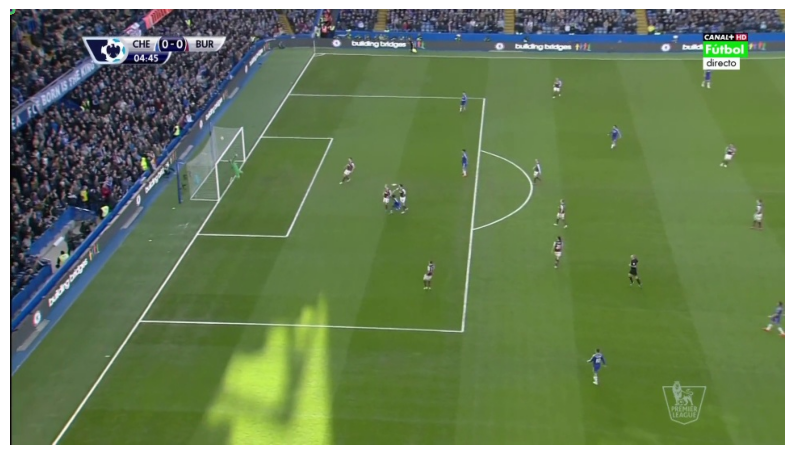

In [27]:
import matplotlib.pyplot as plt

# Extraer keypoints y scores, asegurándose de que sean arrays de NumPy
keypoints = outputs.keypoints[0].detach().cpu().numpy()  # shape: [num_keypoints, 2]
scores = outputs.scores[0].detach().cpu().numpy()        # shape: [num_keypoints]

# Mostrar la imagen
plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")

# Dibujar los keypoints
plt.scatter(
    keypoints[:, 0],  # coordenadas X
    keypoints[:, 1],  # coordenadas Y
    c=scores,         # color basado en el score
    s=scores * 50,    # tamaño basado en el score
    cmap='viridis',
    alpha=0.7
)

plt.show()


In [37]:
from transformers import AutoImageProcessor, SuperPointForKeypointDetection
import torch
from PIL import Image
import requests

url = "00001.jpg"
image_1 = Image.open(url)
url_image_2 = "http://images.cocodataset.org/test-stuff2017/000000000568.jpg"
image_2 = Image.open(requests.get(url_image_2, stream=True).raw)

images = [image_1, image_2]

processor = AutoImageProcessor.from_pretrained("magic-leap-community/superpoint")
model = SuperPointForKeypointDetection.from_pretrained("magic-leap-community/superpoint")

inputs = processor(images, return_tensors="pt")
outputs = model(**inputs)
image_sizes = [(image.height, image.width) for image in images]
outputs = processor.post_process_keypoint_detection(outputs, image_sizes)

for output in outputs:
    for keypoints, scores, descriptors in zip(output["keypoints"], output["scores"], output["descriptors"]):
        print(f"Keypoints: {keypoints}")
        print(f"Scores: {scores}")
        print(f"Descriptors: {descriptors}")

Keypoints: tensor([148,   9], dtype=torch.int32)
Scores: 0.008842138573527336
Descriptors: tensor([ 2.1354e-02, -2.0292e-02,  2.9784e-02,  1.5431e-02,  2.1931e-02,  7.9260e-02, -4.7947e-03,  4.2691e-02,  5.0656e-02,  6.7722e-02,  9.2259e-03, -8.8024e-03, -9.7462e-04, -3.5487e-02, -2.9718e-02,  5.1633e-03,  1.0131e-01, -8.5080e-02,  2.9593e-02,  1.1676e-03, -5.9526e-02,  1.0579e-01,  1.4070e-01,  5.7698e-02,
        -2.4828e-02, -7.3941e-02, -1.0725e-02,  1.6095e-02, -1.6700e-01,  8.1602e-02, -5.4108e-02, -1.2233e-01,  6.7455e-02, -2.8807e-03, -6.8246e-02,  1.1596e-01, -3.5063e-02, -9.8104e-02,  3.0922e-02,  1.5703e-02, -2.7442e-02,  4.1476e-02,  7.1788e-02, -6.1545e-02, -3.0902e-02, -5.8391e-02,  1.6085e-02,  4.7799e-02,
        -4.1926e-02,  1.5110e-02, -3.0476e-02, -3.3914e-02, -8.6811e-02, -1.1607e-02,  5.1916e-02, -1.9193e-02,  2.7593e-02, -4.3727e-02,  2.7075e-02,  2.8727e-02, -5.0357e-02,  7.5442e-02, -2.1311e-02, -6.8363e-02, -2.3245e-02, -1.2004e-04,  8.0196e-02,  4.2054e-02, -

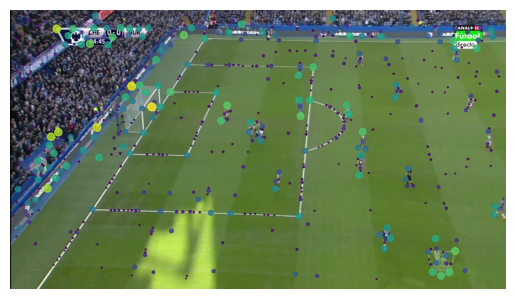

In [32]:
import matplotlib.pyplot as plt

plt.axis("off")
plt.imshow(image_1)
plt.scatter(
    outputs[0]["keypoints"][:, 0].detach().cpu().numpy(),
    outputs[0]["keypoints"][:, 1].detach().cpu().numpy(),
    c=(outputs[0]["scores"] * 100).detach().cpu().numpy(),
    s=(outputs[0]["scores"] * 50).detach().cpu().numpy(),
    alpha=0.8
)
plt.savefig(f"output_image.png")